In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
omega = 0.5

### Functions

In [4]:
def within(x, domain):
    return domain[0] <= x <= domain[1]

In [29]:
def acc(x1, x2, a, b, omega=omega):
    inner = lambda t: x1 + x2*(t - a) + omega*(t - a)**2/2
    speed = lambda t: x2 + omega*(t - a)
    inner.x1 = x1; inner.x2 = x2; inner.domain = [a, b]; inner.speed = speed
    return inner

In [30]:
def dec(x1, x2, a, b, omega=omega):
    inner = lambda t: x1 + x2*(t - a) - omega*(t - a)**2/2
    speed = lambda t: x2 - omega*(t - a)
    inner.x1 = x1; inner.x2 = x2; inner.domain = [a, b]; inner.speed = speed
    return inner

In [31]:
def full(p, a, b):
    inner = lambda t: p + t - a
    inner.p = p; inner.domain = [a, b]; inner.speed = 1
    return inner

In [32]:
def still(p, a, b):
    inner = lambda t: p + t - t
    inner.p = p; inner.domain = [a, b]; inner.speed = 0
    return inner

In [33]:
def plot(*trajectories, domain=True, dt=0.001):
    for trajectory in trajectories:
        tt = np.arange(*trajectory.domain, dt)
        plt.plot(tt, trajectory(tt), lw=1, color='k')
        if domain:
            plt.gca().axvline(x=trajectory.domain[0], linestyle='--', lw=1, color='k')
            plt.gca().axvline(x=trajectory.domain[1], linestyle='--', lw=1, color='k')

In [34]:
def save(name):
    ax = plt.gca()
    ax.axis('off')
    plt.gcf().set_size_inches(5, 5)
    plt.savefig(name)
    plt.show()

### Joining

In [11]:
def join_fs(f1, s1):
    tau2 = s1.p - f1.p + f1.domain[0] + 1/(2*omega)
    tau1 = tau2 - 1/omega

    if within(tau1, f1.domain) and within(tau2, s1.domain):    
        return dec(f1(tau1), f1.speed, tau1, tau2)

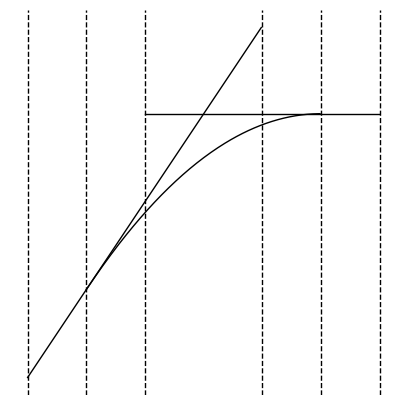

In [13]:
f1 = full(0, 0, 2)
s1 = still(1.5, 1, 3)
d1 = join_fs(f1, s1)
plot(f1, s1, d1)
save('lemma_full_still.pdf')

In [14]:
# join full speed line and full acceleration
def join_fline_acc(l, a1):
    a = a1.domain[0]
    p = a1.x1
    tau = a + 1/omega - math.sqrt((a - p + 1/(2*omega) - l) / omega)
    q = 2*tau - a - 1/omega - l

    return dec(q, 1, q + l, tau)

In [8]:
def f_line(l, a, b):
    inner = lambda t: t - l
    inner.domain = [a, b]
    return inner

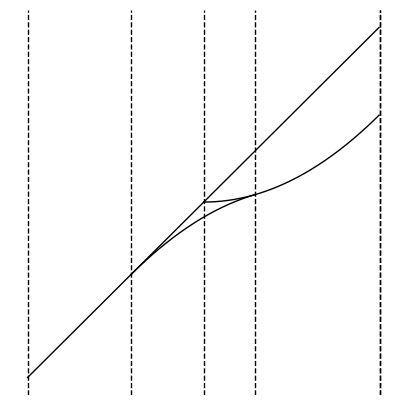

In [18]:
l = 4
l1 = f_line(l, 0, 4)
p = -2
a = 2
a1 = acc(p, 0, a, a+1/omega)
d1 = join_fline_acc(l, a1)
plot(l1, a1, d1)
save('lemma_line_acc.pdf')

In [19]:
def join_fa(f1, a1):
    c = f1.domain[0]
    l = c - f1.p

    x1, x2 = a1.x1, a1.x2
    e, f = a1.domain
    p = x1 - x2**2/(2*omega)
    a = e - x2/omega

    tau2 = a + 1/omega - math.sqrt((a - p + 1/(2*omega) - l) / omega)
    q = 2*tau2 - a - 1/omega - l
    tau1 = q + l

    if within(tau1, f1.domain) and within(tau2, a1.domain):
        return dec(q, 1, tau1, tau2)

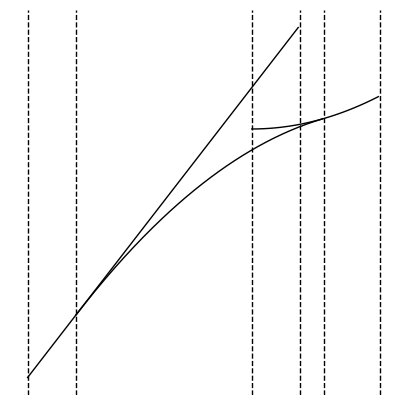

In [20]:
f1 = full(-3.2, 0.8, 2.5)
a1 = acc(p, 0, 2.2, 3)
d1 = join_fa(f1, a1)
plot(f1, a1, d1)
save('lemma_full_acc.pdf')

In [21]:
# join full acceleration and horizontal line
def join_acc_hline(a1, q):
    a = a1.domain[0]
    p = a1.x1
    tau1 = a + math.sqrt((q-p)/omega)
    tau2 = 2*tau1 - a
    return dec(a1(tau1), a1.speed(tau1), tau1, tau2)

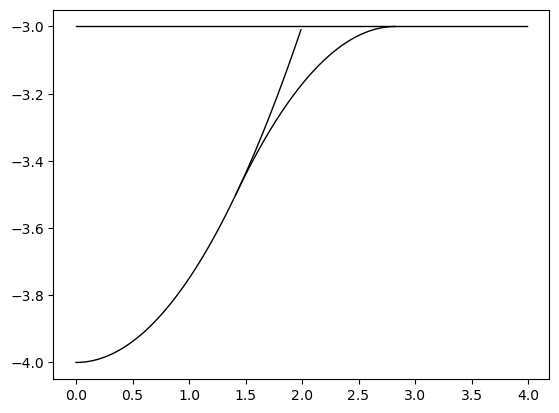

In [22]:
l = -3
h1 = still(l, 0, 4)
a1 = acc(-4, 0, 0, 2)
d1 = join_acc_hline(a1, l)
plot(h1, a1, d1, domain=False)

In [23]:
def join_as(a1, s1):
    q = s1.p
    x1, x2 = a1.x1, a1.x2
    c, d = a1.domain
    
    p = x1 - x2**2/(2*omega)
    a = c - x2/omega

    tau1 = a + math.sqrt((q-p)/omega)
    tau2 = 2*tau1 - a

    if within(tau1, a1.domain) and within(tau2, s1.domain):
        return dec(a1(tau1), a1.speed(tau1), tau1, tau2)

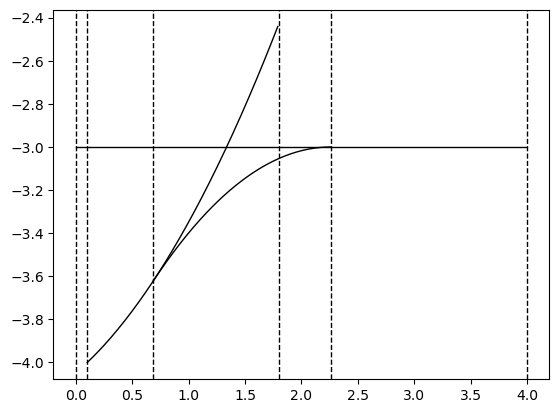

In [24]:
l = -3
h1 = still(l, 0, 4)
a1 = acc(-4, 0.5, 0.1, 1.8)
d1 = join_as(a1, h1)
plot(h1, a1, d1, domain=True)

In [1]:
# TODO: def join_aa(a1, a2)

### Exit joining

Let $t_2$ be the scheduled crossing time of the downstream intersection $w$. We draw the corresponding exit boundary $\bar{x}''$. At regularly spaced positions $\tau_2$, we draw a touching partial deceleration trajectory. This illustrates that, for any boundary $\bar{x}'$, there must be such a deceleration part that joins the two boundaries together.

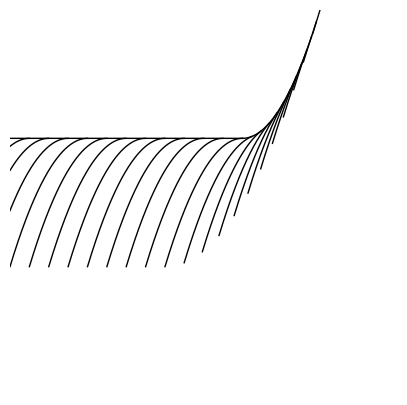

In [132]:
tmin, tmax = 0, 10
t2 = 8

# plot exit boundary
s1 = still(-1/(2*omega), tmin, t2-1/omega)
a1 = acc(-1/(2*omega), 0, t2-1/omega, t2)

plot(s1, a1, domain=False)
ax = plt.gca()
ax.set_xlim([tmin, tmax]);
ax.set_ylim([-3, 0]);

# step size moving along the curve
step_size = 0.5

# plot regularly spaced decelerations on still part
for tau2 in np.arange(*s1.domain, step_size):
    d2 = dec(-1/omega, 1, tau2 - 1/omega, tau2)
    plot(d2, domain=False)

from scipy.optimize import newton
# compute the time corresponding to achieve a 
# certain arc length on the standard acceleration parabola
def arc_length_inverse(l):
    f = lambda t: t*math.sqrt(1 + omega**2*t**2)/2 + math.log(omega*t + math.sqrt(1 + omega**2*t**2))/(2*omega) - l
    return newton(f, 0)

l = 0
while True:
    # using half the arc length turns out to 
    # produce the nicest figure, not sure why though
    tau2 = a1.domain[0] + arc_length_inverse(l) / 2
    if not within(tau2, a1.domain): break
    dt = (1 - a1.speed(tau2)) / omega
    dx = dec(0, 1, 0, 1/omega)(dt)
    d2 = dec(a1(tau2) - dx, 1, tau2 - dt, tau2)
    plot(d2, domain=False)
    l += step_size

save('figures/exit_boundary.pdf')